#### MPAS time series plotting
- Read MPAS cells
- Specify location  
- Read MPAS and interpolate data 
- Create the figure

In [2]:
%matplotlib inline
 
import numpy as np
import xarray as xr

import matplotlib.tri as tri
import matplotlib.pyplot as plt
 
from scipy.interpolate import griddata 

#### Read MPAS Cells

In [3]:
dir_data = '/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/240km_uniform/'
flnm_ini = dir_data + 'x1.10242.init.nc'
ds_i = xr.open_dataset(flnm_ini)
ds_i = ds_i.squeeze()

# Convert to degrees from radians
ds_i["lonCell"] = np.degrees(ds_i.lonCell)
ds_i["latCell"] = np.degrees(ds_i.latCell)

# For Global tripcolor plot
# Add cyclic point before computing the triangulation
ds_i["lonCell"] = ((ds_i["lonCell"] + 180) % 360) - 180

# MPAS data point coordinates.
points = np.array([ds_i["lonCell"].values , ds_i["latCell"].values]).transpose()

triang = tri.Triangulation(ds_i.lonCell, ds_i.latCell)

#### specify the location 

In [4]:
# # Create the start point and end point for the cross section
# Points at which to interpolate data.
lat_pt, lon_pt = (39,-110) 

##### Read MPAS data  

In [16]:
# the variable to be interpolated 
var_s = 't2m'

data_1d = np.empty((8))

for nh in np.arange(8):
    hh_s = str(nh*3).zfill(2)
    flnm = dir_data + 'diag.2014-09-10_' + hh_s + '.00.00.nc'
    ds = xr.open_dataset(flnm)
    ds = ds.squeeze()
    t2 = ds[var_s]
    data_1d[nh] = griddata(points, t2.values, (lon_pt, lat_pt), method='nearest')

#### Time series plotting

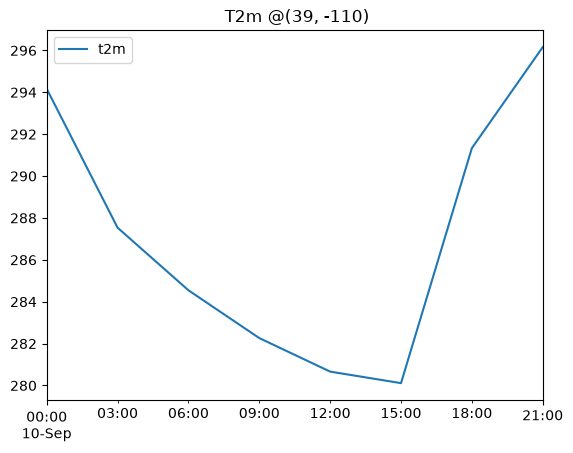

In [18]:
import pandas as pd
 
datetime = pd.date_range('2014-09-10 00', periods=8,  freq='3h')

df = pd.DataFrame(data = data_1d, 
                  index = datetime,
                  columns = ['t2m'])

df.plot(title=' T2m @(39, -110)');
 